# FloodValue v2 — максимум по ML-критериям (Sen1Floods11, Colab A100)

Что добавлено к v1 и **на какой критерий ТЗ работает**:

| Блок | Критерий |
|---|---|
| QC всех слоёв + проверка пространственных пересечений чипов между частями разбиения | 1, 6 |
| Baseline: 3 пороговых варианта (VH, VV, Otsu по VH на чип), выбор **по CV**, не по test | 2 |
| Слабая разметка Sen1Floods11 (4 384 чипа, метки из **S2**, Колумбия — только в обучении), предобучение → дообучение на ручных метках | 3, 7, 8 |
| Контролируемые эксперименты: v1-конфигурация (контроль) · +слабые метки · +сильнее энкодер · ансамбль · **S1+S2 vs S1-only** | 8 |
| Парное сравнение по событиям (победы/поражения), выбор конфигурации только по OOF | 4, 8 |
| Калибровка: none / temperature / Platt / isotonic, **выбор перекрёстной подгонкой по фолдам** | 9 |
| Порог и **постобработка** (удаление мелких компонент): влияние на OOF и test | 5 |
| Test: baseline · v1 · финал на **одних и тех же пикселях**; разбор FP/FN (края, постоянная вода, внутренние области) | 4 |
| Устойчивость: шум, смещение калибровки, пропуски данных; работа без S2 | 7 |
| Неопределённость: AUROC, децили, **risk–coverage**, связь с ошибкой по чипам | 10 |
| Бандл, версии пакетов, sha256 весов, все метрики обоих методов | 11, 12 |

Baseline по ТЗ — **пороговый** (п. 5). Модель v1 остаётся в сравнении как «предыдущая версия основного метода».

Всё пишется в `ROOT/v2/`; v1 (`ROOT/runs`, `ROOT/bundle`) не трогается. Каждый шаг идемпотентен — повторный *Run all* продолжит с места обрыва.

In [2]:
# === 0. Среда ===
!nvidia-smi -L || echo "GPU не найден — Runtime → Change runtime type → A100"
from google.colab import drive
drive.mount('/content/drive')
!pip -q install rasterio "segmentation-models-pytorch>=0.3.3"

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-ba59eb7f-e5ab-1e67-5139-2c1a3c2d1f0a)
Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.1 MB/s eta 0:00:00


In [3]:
# === 1. Конфигурация ===
import os
ROOT  = '/content/drive/MyDrive/floodvalue'
V2    = f'{ROOT}/v2'
LOCAL = '/content/sen1floods11'
SEED, TEST_EVENTS, N_FOLDS = 42, ['Bolivia'], 5

COMMON = dict(epochs=60, patience=12, lr=3e-4, batch=16)
EXPERIMENTS = {
    # контроль = конфигурация v1
    'E1_r34_hand':      dict(arch='Unet', encoder='resnet34', encoder_weights='imagenet', channels=['vv', 'vh', 'ratio'], weak=False, **COMMON),
    # + предобучение на слабых метках S2 (другие чипы тех же обучающих событий + Колумбия)
    'E2_r34_weak':      dict(arch='Unet', encoder='resnet34', encoder_weights='imagenet', channels=['vv', 'vh', 'ratio'], weak=True,
                             pretrain_epochs=8, ft_lr=1.5e-4, **COMMON),
    # + более сильный энкодер
    'E3_effb4_weak':    dict(arch='Unet', encoder='efficientnet-b4', encoder_weights='imagenet', channels=['vv', 'vh', 'ratio'], weak=True,
                             pretrain_epochs=8, ft_lr=1.5e-4, **COMMON),
    # дополнительные данные: S1 + S2 (только для сравнения S1-only vs расширенный; в основной метод не идёт)
    'E4_r34_s1s2_hand': dict(arch='Unet', encoder='resnet34', encoder_weights='imagenet', channels=['vv', 'vh', 'ratio'], weak=False,
                             s2_bands=['B2', 'B3', 'B4', 'B8', 'B11', 'B12'], **COMMON),
}
RUN = ['E1_r34_hand', 'E2_r34_weak', 'E3_effb4_weak', 'E4_r34_s1s2_hand']   # уберите лишнее, если мало времени
ENSEMBLES = {'ENS_E2+E3': ['E2_r34_weak', 'E3_effb4_weak']}                   # кандидаты-ансамбли (только S1-only члены)
REFERENCE_V1 = 'E1_r34_hand'
WEAK_LABEL = 'S2IndexLabelWeak'      # метки из оптики — не повторяют ошибки порога S1
AUG_NOISE_DB, AUG_GAIN_DB, WARMUP = 0.5, 1.0, 0.03
TTA = True
DEMO_CHIP = 'Bolivia_379434'         # тот же демо-чип, что и в v1 (экономика уже на нём)
JRC_PERM_MIN = 1
FORCE_RETRAIN = False

for d in ['runs', 'metrics', 'figures', 'bundle', 'cache']:
    os.makedirs(f'{V2}/{d}', exist_ok=True)
os.makedirs(f'{ROOT}/cache', exist_ok=True); os.makedirs(LOCAL, exist_ok=True)

In [4]:
%%writefile /content/floodvalue_core.py
"""FloodValue core: признаки S1, модель, инференс ансамбля, калибровка, метрики, запись GeoTIFF.
Используется и в обучении (Colab), и в сервисе. Вход — Sentinel-1 VV/VH в dB (дополнительные данные не нужны).
Совместим с бандлами v1 (temperature) и v2 (члены ансамбля разных архитектур + temperature/platt/isotonic)."""
import json, os, math
import numpy as np
import torch
import torch.nn.functional as F

PROB_NODATA = -9999.0
MASK_NODATA = 255

_FEATS = {
    'vv':    lambda vv, vh: vv,
    'vh':    lambda vv, vh: vh,
    'ratio': lambda vv, vh: vv - vh,   # отношение VV/VH в dB
}


def make_features(s1, channels):
    """s1: (..., 2, H, W) [VV, VH] в dB (numpy или torch) -> (..., C, H, W). Только S1-каналы."""
    vv, vh = s1[..., 0, :, :], s1[..., 1, :, :]
    feats = [_FEATS[c](vv, vh) for c in channels if c in _FEATS]
    if isinstance(s1, torch.Tensor):
        return torch.stack(feats, dim=-3)
    return np.stack(feats, axis=-3)


def normalize_torch(x, mean, std):
    m = torch.as_tensor(mean, device=x.device, dtype=x.dtype).view(1, -1, 1, 1)
    s = torch.as_tensor(std, device=x.device, dtype=x.dtype).view(1, -1, 1, 1)
    return torch.nan_to_num((x - m) / s, nan=0.0, posinf=0.0, neginf=0.0)


def build_model(cfg, pretrained=True):
    import segmentation_models_pytorch as smp
    arch = getattr(smp, cfg.get('arch', 'Unet'))
    n_in = len(cfg['channels']) + len(cfg.get('s2_bands', []))
    return arch(encoder_name=cfg['encoder'],
                encoder_weights=cfg.get('encoder_weights') if pretrained else None,
                in_channels=n_in, classes=1)


@torch.no_grad()
def predict_logits(model, x, tta=True):
    """x: (B, C, H, W) нормализованный -> логиты (B, H, W) float32. Любой размер (паддинг до кратного 32)."""
    H, W = x.shape[-2:]
    ph, pw = (32 - H % 32) % 32, (32 - W % 32) % 32
    if ph or pw:
        x = F.pad(x, (0, pw, 0, ph), mode='reflect')
    flips = [(), (-1,), (-2,), (-2, -1)] if tta else [()]
    out = 0
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=x.is_cuda):
        for f in flips:
            xi = torch.flip(x, f) if f else x
            o = model(xi).float()
            out = out + (torch.flip(o, f) if f else o)
    out = out / len(flips)
    return out[:, 0, :H, :W]


def binary_entropy(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def apply_calibration(z, cal):
    """z — логит вероятности (numpy). cal: {'method': none|temperature|platt|isotonic, ...} -> p."""
    m = cal.get('method', 'temperature')
    if m == 'none':
        return 1 / (1 + np.exp(-z))
    if m == 'temperature':
        return 1 / (1 + np.exp(-z / cal['T']))
    if m == 'platt':
        return 1 / (1 + np.exp(-(cal['a'] * z + cal['b'])))
    if m == 'isotonic':
        return np.clip(np.interp(z, cal['x'], cal['y']), 0, 1)
    raise ValueError(m)


def baseline_mask(s1, vh_threshold_db):
    """Пороговый baseline: вода, если VH < порога (dB)."""
    return s1[1] < vh_threshold_db


# ---------- метрики ----------
def confusion(pred, y, valid):
    pred, y, v = pred.astype(bool), y.astype(bool), valid.astype(bool)
    return np.array([(pred & y & v).sum(), (pred & ~y & v).sum(),
                     (~pred & y & v).sum(), (~pred & ~y & v).sum()], dtype=np.int64)


def scores(c):
    tp, fp, fn, tn = [float(v) for v in c]
    div = lambda a, b: (a / b) if b > 0 else None
    return dict(iou=div(tp, tp + fp + fn), f1=div(2 * tp, 2 * tp + fp + fn),
                precision=div(tp, tp + fp), recall=div(tp, tp + fn),
                accuracy=div(tp + tn, tp + fp + fn + tn),
                n_pixels=int(tp + fp + fn + tn), n_water=int(tp + fn),
                tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn))


def clean_json(o):
    """Без NaN/Inf в JSON (требование ТЗ)."""
    if isinstance(o, dict):  return {k: clean_json(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [clean_json(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.bool_): return bool(o)
    if isinstance(o, np.ndarray): return clean_json(o.tolist())
    return o


def save_json(obj, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(clean_json(obj), f, ensure_ascii=False, indent=2, allow_nan=False)


# ---------- ввод/вывод ----------
def read_s1(path):
    """Читает S1 GeoTIFF (2 канала VV, VH в dB). Возвращает (s1 float32 (2,H,W) с NaN для nodata, profile)."""
    import rasterio
    with rasterio.open(path) as src:
        a = src.read().astype(np.float32)
        if src.nodata is not None and np.isfinite(src.nodata):
            a[a == src.nodata] = np.nan
        prof = src.profile.copy()
    if a.shape[0] != 2:
        raise ValueError(f'ожидалось 2 канала VV/VH, получено {a.shape[0]}')
    return a, prof


def write_outputs(out_dir, res, crs, transform, prefix=''):
    """Пишет flood_probability.tif (Float32, nodata -9999), flood_mask.tif (UInt8, 255) и uncertainty-растры."""
    import rasterio
    os.makedirs(out_dir, exist_ok=True)
    H, W = res['prob'].shape
    base = dict(driver='GTiff', height=H, width=W, count=1, crs=crs, transform=transform, compress='deflate')
    valid = res['valid']

    def wr(name, arr, dtype, nodata):
        with rasterio.open(os.path.join(out_dir, prefix + name), 'w', dtype=dtype, nodata=nodata, **base) as dst:
            dst.write(arr.astype(dtype), 1)
    wr('flood_probability.tif', np.where(valid, res['prob'], PROB_NODATA), 'float32', PROB_NODATA)
    wr('flood_mask.tif', np.where(valid, res['mask'].astype(np.uint8), MASK_NODATA), 'uint8', MASK_NODATA)
    wr('uncertainty_entropy.tif', np.where(valid, res['entropy'], PROB_NODATA), 'float32', PROB_NODATA)
    wr('uncertainty_std.tif', np.where(valid, res['std'], PROB_NODATA), 'float32', PROB_NODATA)
    if 'baseline_mask' in res:
        wr('baseline_mask.tif', np.where(valid, res['baseline_mask'].astype(np.uint8), MASK_NODATA), 'uint8', MASK_NODATA)


# ---------- ансамбль для сервиса ----------
class FloodEnsemble:
    """Загрузка бандла и предсказание. Пример:
        ens = FloodEnsemble('bundle'); res = ens.predict_tif('X_S1Hand.tif', 'out/')"""

    def __init__(self, bundle_dir, device=None):
        with open(os.path.join(bundle_dir, 'model_config.json'), encoding='utf-8') as f:
            self.cfg = json.load(f)
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.models = []
        for fd in self.cfg.get('members', self.cfg.get('folds', [])):
            mcfg = fd.get('model', self.cfg.get('model'))
            if mcfg.get('s2_bands'):
                raise ValueError('член ансамбля требует S2 — основной метод должен работать только по S1')
            m = build_model(mcfg, pretrained=False)
            m.load_state_dict(torch.load(os.path.join(bundle_dir, fd['weights']), map_location='cpu'))
            self.models.append((m.eval().to(self.device), mcfg['channels'], fd['norm_mean'], fd['norm_std']))
        self.cal = self.cfg.get('calibration') or {'method': 'temperature', 'T': float(self.cfg.get('temperature', 1.0))}
        self.threshold = float(self.cfg['threshold'])
        self.baseline_thr = float(self.cfg['baseline']['vh_threshold_db'])

    @torch.no_grad()
    def predict(self, s1, tta=True):
        s1 = np.asarray(s1, dtype=np.float32)
        valid = np.isfinite(s1).all(0)
        t = torch.from_numpy(s1)[None].to(self.device)
        raw = []
        for m, ch, mu, sd in self.models:
            lg = predict_logits(m, normalize_torch(make_features(t, ch), mu, sd), tta)[0]
            raw.append(torch.sigmoid(lg).cpu().numpy())
        R = np.stack(raw)
        if 'members' in self.cfg:                     # v2: калибровка вероятности ансамбля
            p = apply_calibration(logit(R.mean(0)), self.cal).astype(np.float32)
        else:                                          # v1: среднее калиброванных вероятностей моделей
            T = self.cal['T']
            p = np.mean([1 / (1 + np.exp(-logit(r) / T)) for r in R], 0).astype(np.float32)
        return dict(prob=p, std=R.std(0), entropy=binary_entropy(p), mask=p >= self.threshold,
                    valid=valid, baseline_mask=baseline_mask(s1, self.baseline_thr), threshold=self.threshold)

    def predict_tif(self, path, out_dir=None, tta=True):
        s1, prof = read_s1(path)
        res = self.predict(s1, tta)
        if out_dir:
            write_outputs(out_dir, res, prof['crs'], prof['transform'])
        return res

Writing /content/floodvalue_core.py


In [5]:
# === 2. Импорты ===
import sys, shutil, json, math, time, glob, hashlib, base64, random, subprocess
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
sys.path.insert(0, '/content'); import importlib, floodvalue_core as fc; importlib.reload(fc)
shutil.copy('/content/floodvalue_core.py', f'{V2}/floodvalue_core.py')
def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_all(SEED); torch.backends.cudnn.benchmark = True
DEV = 'cuda'
print(torch.cuda.get_device_name(0), '| torch', torch.__version__)

NVIDIA A100-SXM4-40GB | torch 2.11.0+cu128


## 3. Данные: скачивание (MD5), кэш на Drive

In [6]:
import requests, rasterio
from concurrent.futures import ThreadPoolExecutor, as_completed
BUCKET = 'sen1floods11'
HAND = 'v1.1/data/flood_events/HandLabeled/'
WEAK = 'v1.1/data/flood_events/WeaklyLabeled/'

def gcs_list(prefix):
    items, token = [], None
    while True:
        p = dict(prefix=prefix, maxResults=1000, fields='items(name,size,md5Hash,updated),nextPageToken')
        if token: p['pageToken'] = token
        js = requests.get(f'https://storage.googleapis.com/storage/v1/b/{BUCKET}/o', params=p, timeout=60).json()
        items += [i for i in js.get('items', []) if i['name'].endswith('.tif') or i['name'].endswith('.csv')]
        token = js.get('nextPageToken')
        if not token: return items

def md5_b64(path):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for b in iter(lambda: f.read(1 << 20), b''): h.update(b)
    return base64.b64encode(h.digest()).decode()

def fetch(item):
    dst = os.path.join(LOCAL, item['name'])
    if os.path.exists(dst) and md5_b64(dst) == item['md5Hash']: return 'skip'
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    for a in range(5):
        try:
            with requests.get(f"https://storage.googleapis.com/{BUCKET}/{item['name']}", stream=True, timeout=120) as r:
                r.raise_for_status()
                with open(dst + '.part', 'wb') as f:
                    for ch in r.iter_content(1 << 20): f.write(ch)
            os.replace(dst + '.part', dst)
            if md5_b64(dst) == item['md5Hash']: return 'ok'
        except Exception: pass
        time.sleep(2 * (a + 1))
    raise RuntimeError(item['name'])

MANIFEST = []
def download(prefixes, desc):
    items = sum((gcs_list(p) for p in prefixes), [])
    st = {'ok': 0, 'skip': 0}
    with ThreadPoolExecutor(32) as ex, tqdm(total=len(items), desc=desc, unit='файл') as bar:
        for fu in as_completed([ex.submit(fetch, it) for it in items]):
            st[fu.result()] += 1; bar.update(1)
    MANIFEST.extend(dict(name=i['name'], url=f"https://storage.googleapis.com/{BUCKET}/{i['name']}", size=int(i['size']),
                         md5_b64=i['md5Hash'], gcs_updated=i.get('updated')) for i in items)
    print(desc, st)

def read_tif(path, nan_nodata=True):
    with rasterio.open(path) as s:
        a = s.read()
        if nan_nodata and a.dtype.kind == 'f' and s.nodata is not None and np.isfinite(s.nodata):
            a[a == s.nodata] = np.nan
        return a, s.crs, s.transform, s.bounds

In [7]:
# --- ручная разметка (+S2Hand для эксперимента E4) ---
HCACHE = f'{V2}/cache/hand.npz'; HMETA = f'{V2}/cache/hand_meta.csv'
need_s2 = any(EXPERIMENTS[e].get('s2_bands') for e in RUN)
if os.path.exists(HCACHE) and os.path.exists(HMETA):
    z = np.load(HCACHE); S1, LBL, JRC = z['S1'], z['LBL'], z['JRC']; S2 = z['S2'] if 'S2' in z.files else None
    meta = pd.read_csv(HMETA); print('hand: из кэша', S1.shape)
else:
    download([HAND + l + '/' for l in ['S1Hand', 'LabelHand', 'JRCWaterHand'] + (['S2Hand'] if need_s2 else [])] + ['v1.1/splits/'], 'HandLabeled')
    files = sorted(glob.glob(f'{LOCAL}/{HAND}S1Hand/*_S1Hand.tif')); N = len(files)
    S1 = np.full((N, 2, 512, 512), np.nan, np.float16); LBL = np.full((N, 512, 512), -1, np.int8)
    JRC = np.zeros((N, 512, 512), np.uint8); S2 = np.zeros((N, 13, 512, 512), np.int16) if need_s2 else None
    rows = []
    for i, f in enumerate(tqdm(files, desc='QC + кэш hand', unit='чип')):
        chip = os.path.basename(f)[:-len('_S1Hand.tif')]; ev = chip.rsplit('_', 1)[0]
        a, crs, tr, bd = read_tif(f); y, crs_l, tr_l, _ = read_tif(f'{LOCAL}/{HAND}LabelHand/{chip}_LabelHand.tif')
        j, *_ = read_tif(f'{LOCAL}/{HAND}JRCWaterHand/{chip}_JRCWaterHand.tif')
        S1[i] = a; LBL[i] = y[0]; JRC[i] = np.clip(j[0], 0, 255)
        r = dict(idx=i, chip_id=chip, event_id=ev, s1_file=os.path.basename(f), crs=crs.to_wkt(), crs_epsg=crs.to_epsg(),
                 transform=json.dumps(list(tr)[:6]), left=bd.left, bottom=bd.bottom, right=bd.right, top=bd.top,
                 shape_ok=a.shape == (2, 512, 512), label_same_grid=bool(crs_l == crs and tr_l.almost_equals(tr)),
                 vv_median_db=float(np.nanmedian(a[0])), vh_median_db=float(np.nanmedian(a[1])),
                 looks_linear=bool(np.nanmedian(a[0]) > 0), s1_nan_frac=float((~np.isfinite(a)).any(0).mean()),
                 label_valid_frac=float((y[0] >= 0).mean()), water_frac=float((y[0] == 1).sum() / max((y[0] >= 0).sum(), 1)),
                 jrc_frac=float((j[0] >= JRC_PERM_MIN).mean()))
        if need_s2:
            s2, crs2, tr2, _ = read_tif(f'{LOCAL}/{HAND}S2Hand/{chip}_S2Hand.tif', nan_nodata=False)
            S2[i] = s2; r['s2_same_grid'] = bool(crs2 == crs and tr2.almost_equals(tr)); r['s2_zero_frac'] = float((s2 == 0).all(0).mean())
        rows.append(r)
    meta = pd.DataFrame(rows)
    np.savez(HCACHE, S1=S1, LBL=LBL, JRC=JRC, **({'S2': S2} if need_s2 else {})); meta.to_csv(HMETA, index=False)
meta.to_csv(f'{V2}/metrics/data_qc_hand.csv', index=False)
print(f"{len(meta)} чипов | проблем формы/сетки/шкалы: {int((~meta.shape_ok | ~meta.label_same_grid | meta.looks_linear).sum())}"
      + (f" | S2 на той же сетке: {int(meta.s2_same_grid.sum())}" if 's2_same_grid' in meta else ''))

HandLabeled:   0%|          | 0/1792 [00:00<?, ?файл/s]

HandLabeled {'ok': 1792, 'skip': 0}


QC + кэш hand:   0%|          | 0/446 [00:00<?, ?чип/s]

/tmp/ipykernel_2822/2771952877.py:21: RuntimeWarning: All-NaN slice encountered
  vv_median_db=float(np.nanmedian(a[0])), vh_median_db=float(np.nanmedian(a[1])),
/tmp/ipykernel_2822/2771952877.py:22: RuntimeWarning: All-NaN slice encountered
  looks_linear=bool(np.nanmedian(a[0]) > 0), s1_nan_frac=float((~np.isfinite(a)).any(0).mean()),


446 чипов | проблем формы/сетки/шкалы: 0 | S2 на той же сетке: 446


In [8]:
# --- слабая разметка: S1Weak + метки из S2 (WEAK_LABEL) ---
WCACHE = f'{V2}/cache/weak.npz'; WMETA = f'{V2}/cache/weak_meta.csv'
need_weak = any(EXPERIMENTS[e].get('weak') for e in RUN)
if need_weak:
    if os.path.exists(WCACHE) and os.path.exists(WMETA):
        t = time.time(); z = np.load(WCACHE); WS1, WLBL = z['S1'], z['LBL']; wmeta = pd.read_csv(WMETA); print(f'weak: из кэша {WS1.shape}, {time.time()-t:.0f} c')
    else:
        download([WEAK + 'S1Weak/', WEAK + WEAK_LABEL + '/'], 'WeaklyLabeled')
        files = sorted(glob.glob(f'{LOCAL}/{WEAK}S1Weak/*_S1Weak.tif')); N = len(files)
        WS1 = np.full((N, 2, 512, 512), np.nan, np.float16); WLBL = np.full((N, 512, 512), -1, np.int8); rows = []
        for i, f in enumerate(tqdm(files, desc='QC + кэш weak', unit='чип')):
            chip = os.path.basename(f)[:-len('_S1Weak.tif')]; ev = chip.rsplit('_', 1)[0]
            a, crs, tr, bd = read_tif(f); lf = f'{LOCAL}/{WEAK}{WEAK_LABEL}/{chip}_{WEAK_LABEL}.tif'
            ok = os.path.exists(lf) and a.shape == (2, 512, 512)
            if ok:
                y, crs_l, tr_l, _ = read_tif(lf); WS1[i] = a; WLBL[i] = np.where(np.isin(y[0], [0, 1]), y[0], -1)
            rows.append(dict(widx=i, chip_id=chip, event_id=ev, ok=ok, left=bd.left, bottom=bd.bottom, right=bd.right, top=bd.top,
                             water_frac=float((WLBL[i] == 1).mean()), valid_frac=float((WLBL[i] >= 0).mean())))
        wmeta = pd.DataFrame(rows); np.savez(WCACHE, S1=WS1, LBL=WLBL); wmeta.to_csv(WMETA, index=False)
    wmeta.to_csv(f'{V2}/metrics/data_qc_weak.csv', index=False)
    display(wmeta.groupby('event_id').agg(chips=('chip_id', 'count'), ok=('ok', 'sum'), water=('water_frac', 'mean')).round(3))

WeaklyLabeled:   0%|          | 0/8768 [00:00<?, ?файл/s]

WeaklyLabeled {'ok': 8768, 'skip': 0}


QC + кэш weak:   0%|          | 0/4384 [00:00<?, ?чип/s]

,chips,ok,water
event_id,,,
Bolivia,224,224,0.083
Colombia,534,534,0.077
Ghana,181,181,0.110
India,467,467,0.092
Mekong,1353,1353,0.215
Nigeria,109,109,0.201
Pakistan,249,249,0.067
Paraguay,316,316,0.064
Somalia,129,129,0.094


## 4. Разбиение и проверка утечек

In [9]:
from sklearn.model_selection import GroupKFold
V1_SPLITS = f'{ROOT}/metrics/splits.csv'
meta['split'] = np.where(meta.event_id.isin(TEST_EVENTS), 'test', 'dev'); meta['fold'] = -1
dev = meta[meta.split == 'dev']
for k, (_, va) in enumerate(GroupKFold(N_FOLDS).split(dev, groups=dev.event_id)):
    meta.loc[dev.index[va], 'fold'] = k
if os.path.exists(V1_SPLITS):   # то же разбиение, что в v1 — сравнение v1/v2 честное
    v1 = pd.read_csv(V1_SPLITS).set_index('chip_id')
    assert (v1.loc[meta.chip_id, 'fold'].values == meta.fold.values).all(), 'разбиение отличается от v1'
    print('Разбиение совпадает с v1 ✔')
meta[['chip_id', 'event_id', 'split', 'fold']].to_csv(f'{V2}/metrics/splits.csv', index=False)
TEST_IDX = meta[meta.split == 'test'].idx.values; DEV_IDX = meta[meta.split == 'dev'].idx.values
FOLD_OF = dict(zip(meta.idx, meta.fold)); EVENT_OF = dict(zip(meta.idx, meta.event_id))
FOLD_EVENTS = {k: sorted(meta[meta.fold == k].event_id.unique()) for k in range(N_FOLDS)}

# --- проверка пространственных пересечений (утечка через соседние/перекрывающиеся окна) ---
from shapely.geometry import box
from shapely.strtree import STRtree
def overlaps(a_df, b_df, tag):
    ga = [box(r.left, r.bottom, r.right, r.top) for r in a_df.itertuples()]
    gb = [box(r.left, r.bottom, r.right, r.top) for r in b_df.itertuples()]
    tree = STRtree(gb); n = 0
    for g in ga:
        n += sum(1 for j in tree.query(g) if g.intersection(gb[j]).area > 0)
    return dict(check=tag, n_intersections=n)
LEAK = [overlaps(meta[meta.split == 'test'], meta[meta.split == 'dev'], 'hand test ∩ hand dev')]
for k in range(N_FOLDS):
    LEAK.append(overlaps(meta[meta.fold == k], meta[(meta.split == 'dev') & (meta.fold != k)], f'hand fold {k} ∩ остальные фолды'))
if need_weak:
    LEAK.append(overlaps(meta[meta.split == 'test'], wmeta[~wmeta.event_id.isin(TEST_EVENTS)], 'hand test ∩ weak (без Bolivia)'))
    for k in range(N_FOLDS):
        LEAK.append(overlaps(meta[meta.fold == k], wmeta[~wmeta.event_id.isin(TEST_EVENTS + FOLD_EVENTS[k])], f'hand fold {k} ∩ weak-обучение фолда'))
leak = pd.DataFrame(LEAK); display(leak); leak.to_csv(f'{V2}/metrics/leakage_check.csv', index=False)
fc.save_json(dict(seed=SEED, test_events=TEST_EVENTS, n_folds=N_FOLDS, method='GroupKFold по event_id (как v1)', fold_events=FOLD_EVENTS,
                  weak_rule='слабые чипы событий test и валидационного фолда исключаются из обучения фолда; Колумбия (нет ручных меток) — всегда в обучении',
                  leakage_check=LEAK), f'{V2}/metrics/splits_protocol.json')

S1_t = torch.from_numpy(S1).to(DEV); LBL_t = torch.from_numpy(LBL).to(DEV)
S2_t = torch.from_numpy(S2).to(DEV) if S2 is not None else None
if need_weak:
    WS1_t = torch.from_numpy(WS1).to(DEV); WLBL_t = torch.from_numpy(WLBL).to(DEV)
print(f'GPU: {torch.cuda.memory_allocated() / 1e9:.1f} ГБ данных')

Разбиение совпадает с v1 ✔


,check,n_intersections
0,hand test ∩ hand dev,0
1,hand fold 0 ∩ остальные фолды,0
2,hand fold 1 ∩ остальные фолды,0
3,hand fold 2 ∩ остальные фолды,0
4,hand fold 3 ∩ остальные фолды,0
5,hand fold 4 ∩ остальные фолды,0
6,hand test ∩ weak (без Bolivia),0
7,hand fold 0 ∩ weak-обучение фолда,0
8,hand fold 1 ∩ weak-обучение фолда,0
9,hand fold 2 ∩ weak-обучение фолда,0


GPU: 9.4 ГБ данных


## 5. Baseline: пороговые варианты, выбор по CV

In [10]:
from skimage.filters import threshold_otsu
GRID = np.round(np.arange(-30, -4.99, 0.25), 2)
@torch.no_grad()
def grid_counts(idx, band):
    out = np.zeros((len(GRID), 4), np.int64); g = torch.tensor(GRID, device=DEV).view(-1, 1)
    for b in range(0, len(idx), 16):
        ii = torch.as_tensor(idx[b:b + 16], device=DEV); s1 = S1_t[ii].float(); y = LBL_t[ii]
        v = (y >= 0) & torch.isfinite(s1).all(1); x = s1[:, band][v].view(1, -1); t = (y[v] == 1).view(1, -1); p = x < g
        out += torch.stack([(p & t).sum(1), (p & ~t).sum(1), (~p & t).sum(1), (~p & ~t).sum(1)], 1).cpu().numpy()
    return out
def best(c):
    iou = c[:, 0] / np.maximum(c[:, 0] + c[:, 1] + c[:, 2], 1); return float(GRID[iou.argmax()]), float(iou.max())
def otsu_pred(i):
    vh = S1[i, 1].astype(np.float32); f = np.isfinite(vh)
    return (vh < threshold_otsu(vh[f])) if f.sum() > 100 else np.zeros_like(f)

BASE = {}
for name, band in [('VH_global', 1), ('VV_global', 0)]:
    fcnt = {k: grid_counts(DEV_IDX[[FOLD_OF[i] == k for i in DEV_IDX]], band) for k in range(N_FOLDS)}
    cv = []
    for k in range(N_FOLDS):
        thr, _ = best(sum(fcnt[j] for j in range(N_FOLDS) if j != k)); cv.append(fcnt[k][list(GRID).index(thr)])
    BASE[name] = dict(band=band, thr=best(sum(fcnt.values()))[0], cv=fc.scores(sum(cv)),
                      fold_thr=[best(sum(fcnt[j] for j in range(N_FOLDS) if j != k))[0] for k in range(N_FOLDS)])
BASE['VH_otsu_per_chip'] = dict(band=1, thr=None, cv=fc.scores(sum(fc.confusion(otsu_pred(i), LBL[i] == 1, (LBL[i] >= 0) & np.isfinite(S1[i]).all(0)) for i in DEV_IDX)))
bt = pd.DataFrame([dict(variant=k, threshold_db=v['thr'], **{m: v['cv'][m] for m in ['iou', 'f1', 'precision', 'recall']}) for k, v in BASE.items()])
BASE_NAME = bt.sort_values('iou', ascending=False).variant.iloc[0]
display(bt.round(4)); print('Baseline (лучший по CV, test не используется):', BASE_NAME)
def base_pred(i):
    b = BASE[BASE_NAME]
    return otsu_pred(i) if BASE_NAME == 'VH_otsu_per_chip' else S1[i, b['band']].astype(np.float32) < b['thr']
bt.to_csv(f'{V2}/metrics/baseline_variants_cv.csv', index=False)
fc.save_json(dict(selected=BASE_NAME, rule='max pooled CV IoU (порог выбирается на остальных фолдах)', variants=BASE),
             f'{V2}/metrics/baseline.json')

,variant,threshold_db,iou,f1,precision,recall
0,VH_global,-23.25,0.4853,0.6535,0.6758,0.6326
1,VV_global,-16.75,0.4374,0.6086,0.7168,0.5287
2,VH_otsu_per_chip,NaN,0.2031,0.3377,0.2184,0.7434


Baseline (лучший по CV, test не используется): VH_global


## 6. Обучение: предобучение на слабых метках → дообучение на ручных, CV по событиям
Внешний бар — эпохи, внутренний — батчи; после эпохи печатаются метрики валидации. Каждая стадия пишет `last.pt` и продолжается после обрыва.

In [11]:
S2_IDX = {'B1': 0, 'B2': 1, 'B3': 2, 'B4': 3, 'B5': 4, 'B6': 5, 'B7': 6, 'B8': 7, 'B8A': 8, 'B9': 9, 'B10': 10, 'B11': 11, 'B12': 12}

def get_batch(src, ii):
    if src == 'hand': return S1_t[ii].float(), LBL_t[ii].long(), (S2_t[ii].float() if S2_t is not None else None)
    return WS1_t[ii].float(), WLBL_t[ii].long(), None

def features(s1, s2, cfg, mean, std):
    x = fc.make_features(s1, cfg['channels'])
    if cfg.get('s2_bands'):
        b = s2[:, [S2_IDX[n] for n in cfg['s2_bands']]] / 10000.0
        b = torch.where(b > 0, b, torch.full_like(b, float('nan')))
        x = torch.cat([x, b], 1)
    return fc.normalize_torch(x, mean, std)

def norm_stats(tr, cfg, n=160):
    sel = np.random.default_rng(SEED).choice(tr, min(n, len(tr)), replace=False); acc = None
    for b in range(0, len(sel), 16):
        ii = torch.as_tensor(sel[b:b + 16], device=DEV); s1, _, s2 = get_batch('hand', ii)
        f = fc.make_features(s1, cfg['channels'])
        if cfg.get('s2_bands'):
            bb = s2[:, [S2_IDX[n] for n in cfg['s2_bands']]] / 10000.0; f = torch.cat([f, torch.where(bb > 0, bb, torch.full_like(bb, float('nan')))], 1)
        C = f.shape[1]; fl = f.permute(1, 0, 2, 3).reshape(C, -1).double(); v = torch.isfinite(fl)
        s = torch.where(v, fl, 0).sum(1); s2_ = torch.where(v, fl ** 2, 0).sum(1); c = v.sum(1)
        acc = (s, s2_, c) if acc is None else (acc[0] + s, acc[1] + s2_, acc[2] + c)
    m = acc[0] / acc[2]; sd = (acc[1] / acc[2] - m ** 2).clamp_min(1e-8).sqrt()
    return m.cpu().tolist(), sd.cpu().tolist()

def augment(s1, y, s2):
    for i in range(s1.shape[0]):
        k = int(torch.randint(0, 4, (1,))); fl = bool(torch.rand(1) < 0.5)
        for t, d in [[s1, (1, 2)], [y, (0, 1)]] + ([[s2, (1, 2)]] if s2 is not None else []):
            if k: t[i] = torch.rot90(t[i], k, d)
            if fl: t[i] = torch.flip(t[i], (d[1],))
    gain = (torch.rand(s1.shape[0], 1, 1, 1, device=DEV) - 0.5) * 2 * AUG_GAIN_DB
    return s1 + gain + torch.randn_like(s1) * AUG_NOISE_DB, y, s2

def masked_loss(lg, t, v):
    v = v.float(); t = t.float()
    bce = (F.binary_cross_entropy_with_logits(lg, t, reduction='none') * v).sum() / v.sum().clamp_min(1)
    p = torch.sigmoid(lg) * v
    return bce + 1 - (2 * (p * t).sum() + 1) / (p.sum() + (t * v).sum() + 1)

@torch.no_grad()
def run_eval(model, idx, cfg, mean, std, tta=False, keep=False, bs=8, s1_override=None):
    model.eval(); conf = np.zeros(4, np.int64); ls = 0.; outs = []
    for b in range(0, len(idx), bs):
        ii = torch.as_tensor(idx[b:b + bs], device=DEV); s1, y, s2 = get_batch('hand', ii)
        if s1_override is not None: s1 = s1_override(s1)
        v = (y >= 0) & torch.isfinite(S1_t[ii].float()).all(1)
        lg = fc.predict_logits(model, features(s1, s2, cfg, mean, std), tta)
        ls += masked_loss(lg, y == 1, v).item() * len(ii); p = lg > 0; t = y == 1
        conf += np.array([(p & t & v).sum().item(), (p & ~t & v).sum().item(), (~p & t & v).sum().item(), (~p & ~t & v).sum().item()])
        if keep: outs.append(lg.half().cpu().numpy())
    return conf, ls / max(len(idx), 1), (np.concatenate(outs) if keep else None)

def run_stage(model, cfg, stage, fdir, items, va, mean, std, epochs, lr, patience, k):
    # items: np.array [(src 0=hand/1=weak, idx)]; возвращает best IoU; best.pt = лучшая по val
    sd = f'{fdir}/{stage}'; os.makedirs(sd, exist_ok=True)
    if os.path.exists(f'{sd}/done.json') and not FORCE_RETRAIN:
        model.load_state_dict(torch.load(f'{sd}/best.pt', map_location=DEV)); return json.load(open(f'{sd}/done.json'))
    B = cfg['batch']; steps = len(items) // B; total = steps * epochs; warm = max(1, int(WARMUP * total))
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: (s + 1) / warm if s < warm else 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, total - warm))))
    start, best, best_ep, bad, hist = 0, -1., 0, 0, []
    if os.path.exists(f'{sd}/last.pt') and not FORCE_RETRAIN:
        ck = torch.load(f'{sd}/last.pt', map_location=DEV, weights_only=False)
        model.load_state_dict(ck['model']); opt.load_state_dict(ck['opt']); sch.load_state_dict(ck['sched'])
        start, best, best_ep, bad, hist = ck['epoch'], ck['best'], ck['best_ep'], ck['bad'], ck['hist']
        print(f'  продолжаю {stage} с эпохи {start + 1}')
    bar = tqdm(range(start, epochs), desc=f'{os.path.basename(os.path.dirname(fdir))} f{k} {stage}', initial=start, total=epochs, unit='эп')
    for ep in bar:
        if bad >= patience: break
        model.train(); torch.manual_seed(SEED * 1000 + k * 100 + ep)
        perm = items[np.random.default_rng(SEED * 1000 + k * 100 + ep).permutation(len(items))]; tl = 0.
        ib = tqdm(range(steps), leave=False, desc=f'эпоха {ep + 1}', unit='batch')
        for s in ib:
            bi = perm[s * B:(s + 1) * B]; parts = []
            for src, name in [(0, 'hand'), (1, 'weak')]:
                sel = bi[bi[:, 0] == src, 1]
                if len(sel): parts.append(get_batch(name, torch.as_tensor(sel, device=DEV)))
            s1 = torch.cat([p[0] for p in parts]); y = torch.cat([p[1] for p in parts])
            s2 = torch.cat([p[2] for p in parts]) if cfg.get('s2_bands') else None
            s1, y, s2 = augment(s1, y, s2); v = (y >= 0) & torch.isfinite(s1).all(1)
            x = features(s1, s2, cfg, mean, std).contiguous(memory_format=torch.channels_last)
            with torch.autocast('cuda', dtype=torch.bfloat16): lg = model(x)[:, 0]
            loss = masked_loss(lg.float(), y == 1, v); opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sch.step(); tl += loss.item()
            ib.set_postfix(loss=f'{tl / (s + 1):.4f}')
        conf, vl, _ = run_eval(model, va, cfg, mean, std); sc = fc.scores(conf); iou = sc['iou'] or 0.; imp = iou > best
        if imp: best, best_ep, bad = iou, ep + 1, 0; torch.save(model.state_dict(), f'{sd}/best.pt')
        else: bad += 1
        hist.append(dict(epoch=ep + 1, train_loss=tl / steps, val_loss=vl, **{m: sc[m] for m in ['iou', 'f1', 'precision', 'recall']}))
        tqdm.write(f"  [{stage}] ep {ep + 1:3d} | train {tl / steps:.4f} | val {vl:.4f} | IoU {iou:.4f} F1 {sc['f1'] or 0:.4f} "
                   f"P {sc['precision'] or 0:.4f} R {sc['recall'] or 0:.4f}{'  ★' if imp else ''}")
        bar.set_postfix(best=f'{best:.4f}', ep=best_ep)
        torch.save(dict(model=model.state_dict(), opt=opt.state_dict(), sched=sch.state_dict(), epoch=ep + 1, best=best,
                        best_ep=best_ep, bad=bad, hist=hist), f'{sd}/last.pt.tmp'); os.replace(f'{sd}/last.pt.tmp', f'{sd}/last.pt')
    pd.DataFrame(hist).to_csv(f'{sd}/history.csv', index=False)
    model.load_state_dict(torch.load(f'{sd}/best.pt', map_location=DEV))
    d = dict(stage=stage, best_val_iou=best, best_epoch=best_ep, epochs_run=len(hist)); fc.save_json(d, f'{sd}/done.json'); return d

def train_fold(exp, k):
    cfg = EXPERIMENTS[exp]; fdir = f'{V2}/runs/{exp}/fold_{k}'; os.makedirs(fdir, exist_ok=True)
    if os.path.exists(f'{fdir}/done.json') and not FORCE_RETRAIN:
        d = json.load(open(f'{fdir}/done.json')); print(f'[{exp} f{k}] готов: val IoU {d["best_val_iou"]:.4f}'); return d
    tr = np.array([i for i in DEV_IDX if FOLD_OF[i] != k]); va = np.array([i for i in DEV_IDX if FOLD_OF[i] == k])
    mean, std = norm_stats(tr, cfg); seed_all(SEED + k)
    model = fc.build_model(cfg, pretrained=True).to(DEV).to(memory_format=torch.channels_last)
    hand_items = np.stack([np.zeros(len(tr), int), tr], 1)
    print(f'[{exp} f{k}] train события {sorted(set(EVENT_OF[i] for i in tr))} | val {FOLD_EVENTS[k]}')
    stages = []
    if cfg.get('weak'):
        wtr = wmeta[wmeta.ok & ~wmeta.event_id.isin(TEST_EVENTS + FOLD_EVENTS[k])].widx.values
        items = np.concatenate([np.stack([np.ones(len(wtr), int), wtr], 1), hand_items, hand_items])   # ручные ×2
        print(f'  pretrain: {len(wtr)} слабых + {len(tr)}×2 ручных чипов')
        stages.append(run_stage(model, cfg, 'pretrain', fdir, items, va, mean, std, cfg['pretrain_epochs'], cfg['lr'], 99, k))
        stages.append(run_stage(model, cfg, 'finetune', fdir, hand_items, va, mean, std, cfg['epochs'], cfg['ft_lr'], cfg['patience'], k))
    else:
        stages.append(run_stage(model, cfg, 'train', fdir, hand_items, va, mean, std, cfg['epochs'], cfg['lr'], cfg['patience'], k))
    final = stages[-1]
    if cfg.get('weak') and stages[0]['best_val_iou'] > final['best_val_iou']:   # дообучение не помогло → берём предобученную
        model.load_state_dict(torch.load(f'{fdir}/pretrain/best.pt', map_location=DEV)); final = stages[0]
    torch.save(model.state_dict(), f'{fdir}/best.pt')
    conf, _, lg = run_eval(model, va, cfg, mean, std, tta=TTA, keep=True)
    np.savez(f'{fdir}/oof_logits.npz', idx=va, logits=lg)
    fig, ax = plt.subplots(1, len(stages), figsize=(6 * len(stages), 3.2), squeeze=False)
    for a_, st in zip(ax[0], stages):
        h = pd.read_csv(f"{fdir}/{st['stage']}/history.csv"); h.plot(x='epoch', y=['iou', 'f1', 'precision', 'recall'], ax=a_); a_.set_title(f"{exp} f{k} {st['stage']}")
    plt.tight_layout(); plt.savefig(f'{fdir}/curves.png', dpi=70); plt.show()
    d = dict(exp=exp, fold=k, stages=stages, best_val_iou=final['best_val_iou'], chosen_stage=final['stage'], norm_mean=mean, norm_std=std,
             oof_tta=fc.scores(conf), val_events=FOLD_EVENTS[k])
    fc.save_json(d, f'{fdir}/done.json'); fc.save_json(cfg, f'{V2}/runs/{exp}/config.json'); return d

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

[E1_r34_hand f0] train события ['Ghana', 'India', 'Mekong', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka'] | val ['Nigeria', 'USA']


E1_r34_hand f0 train:   0%|          | 0/60 [00:00<?, ?эп/s]

...

  [train] ep  43 | train 0.3577 | val 0.4329 | IoU 0.6716 F1 0.8035 P 0.8624 R 0.7522


эпоха 44:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  44 | train 0.3349 | val 0.4305 | IoU 0.6805 F1 0.8099 P 0.8577 R 0.7671


эпоха 45:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  45 | train 0.3252 | val 0.4333 | IoU 0.6755 F1 0.8063 P 0.8299 R 0.7841


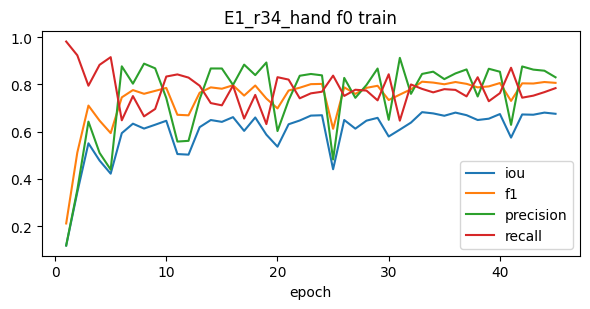

[E1_r34_hand f1] train события ['Ghana', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Spain', 'Sri-Lanka', 'USA'] | val ['India', 'Somalia']


E1_r34_hand f1 train:   0%|          | 0/60 [00:00<?, ?эп/s]

эпоха 1:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep   1 | train 1.3938 | val 1.7442 | IoU 0.1383 F1 0.2430 P 0.1397 R 0.9341  ★


эпоха 2:   0%|          | 0/21 [00:00<?, ?batch/s]

...

  [train] ep  36 | train 0.3037 | val 0.7445 | IoU 0.4437 F1 0.6147 P 0.7426 R 0.5243


эпоха 37:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  37 | train 0.3082 | val 0.9170 | IoU 0.3662 F1 0.5360 P 0.4171 R 0.7498


эпоха 38:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  38 | train 0.3008 | val 0.7594 | IoU 0.4549 F1 0.6254 P 0.7327 R 0.5455


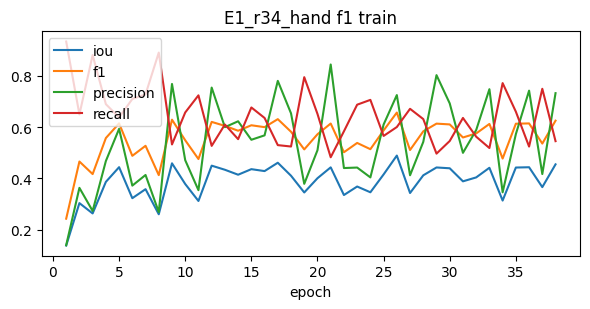

[E1_r34_hand f2] train события ['Ghana', 'India', 'Mekong', 'Nigeria', 'Somalia', 'Spain', 'Sri-Lanka', 'USA'] | val ['Pakistan', 'Paraguay']


E1_r34_hand f2 train:   0%|          | 0/60 [00:00<?, ?эп/s]

эпоха 1:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep   1 | train 1.2447 | val 2.0473 | IoU 0.1421 F1 0.2489 P 0.1427 R 0.9733  ★


эпоха 2:   0%|          | 0/21 [00:00<?, ?batch/s]

...

  [train] ep  29 | train 0.3685 | val 0.6020 | IoU 0.4852 F1 0.6534 P 0.6331 R 0.6751


эпоха 30:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  30 | train 0.3822 | val 0.5795 | IoU 0.5061 F1 0.6721 P 0.6063 R 0.7539


эпоха 31:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  31 | train 0.3547 | val 0.6051 | IoU 0.4792 F1 0.6479 P 0.6510 R 0.6449


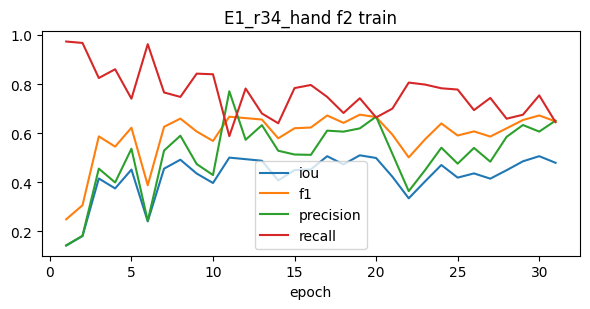

[E1_r34_hand f3] train события ['India', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka', 'USA'] | val ['Ghana', 'Mekong']


E1_r34_hand f3 train:   0%|          | 0/60 [00:00<?, ?эп/s]

эпоха 1:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep   1 | train 1.4452 | val 1.6032 | IoU 0.1845 F1 0.3116 P 0.1847 R 0.9947  ★


эпоха 2:   0%|          | 0/21 [00:00<?, ?batch/s]

...

  [train] ep  22 | train 0.4397 | val 0.4842 | IoU 0.7609 F1 0.8642 P 0.8268 R 0.9051


эпоха 23:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  23 | train 0.4632 | val 0.5102 | IoU 0.7657 F1 0.8673 P 0.8873 R 0.8482


эпоха 24:   0%|          | 0/21 [00:00<?, ?batch/s]

  [train] ep  24 | train 0.4399 | val 0.4693 | IoU 0.7757 F1 0.8737 P 0.8537 R 0.8946


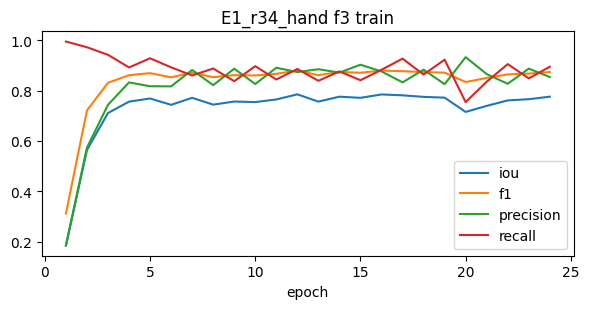

[E1_r34_hand f4] train события ['Ghana', 'India', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia', 'USA'] | val ['Spain', 'Sri-Lanka']


E1_r34_hand f4 train:   0%|          | 0/60 [00:00<?, ?эп/s]

эпоха 1:   0%|          | 0/22 [00:00<?, ?batch/s]

  [train] ep   1 | train 1.5252 | val 1.8208 | IoU 0.1496 F1 0.2602 P 0.1499 R 0.9872  ★


эпоха 2:   0%|          | 0/22 [00:00<?, ?batch/s]

...

  [train] ep  36 | train 0.3640 | val 0.4268 | IoU 0.6761 F1 0.8068 P 0.8143 R 0.7994


эпоха 37:   0%|          | 0/22 [00:00<?, ?batch/s]

  [train] ep  37 | train 0.3681 | val 0.4826 | IoU 0.6453 F1 0.7844 P 0.8775 R 0.7092


эпоха 38:   0%|          | 0/22 [00:00<?, ?batch/s]

  [train] ep  38 | train 0.3909 | val 0.4370 | IoU 0.6662 F1 0.7997 P 0.7969 R 0.8025


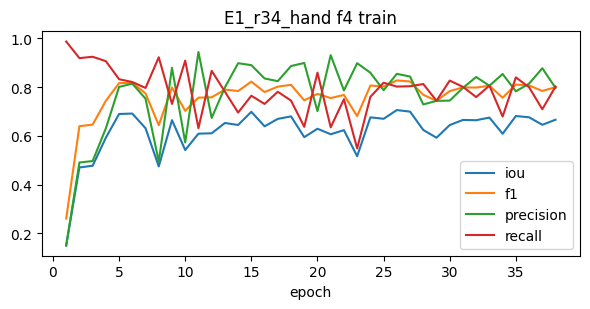

=== E1_r34_hand: 8.7 мин ===
[E2_r34_weak f0] train события ['Ghana', 'India', 'Mekong', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka'] | val ['Nigeria', 'USA']
  pretrain: 3565 слабых + 344×2 ручных чипов


E2_r34_weak f0 pretrain:   0%|          | 0/8 [00:00<?, ?эп/s]

эпоха 1:   0%|          | 0/265 [00:00<?, ?batch/s]

  [pretrain] ep   1 | train 0.8376 | val 0.5781 | IoU 0.6323 F1 0.7747 P 0.8488 R 0.7125  ★


эпоха 2:   0%|          | 0/265 [00:00<?, ?batch/s]

...

эпоха 3:   0%|          | 0/265 [00:00<?, ?batch/s]

  [pretrain] ep   3 | train 0.5290 | val 0.4846 | IoU 0.6529 F1 0.7900 P 0.8253 R 0.7575


эпоха 4:   0%|          | 0/265 [00:00<?, ?batch/s]

  [pretrain] ep   4 | train 0.5248 | val 0.4778 | IoU 0.6621 F1 0.7967 P 0.8578 R 0.7437  ★


эпоха 5:   0%|          | 0/265 [00:00<?, ?batch/s]

In [ ]:
FOLD_RESULTS = {}
for exp in RUN:
    t0 = time.time()
    FOLD_RESULTS[exp] = [train_fold(exp, k) for k in range(N_FOLDS)]
    torch.cuda.empty_cache(); print(f'=== {exp}: {(time.time() - t0) / 60:.1f} мин ===')

## 7. Выбор конфигурации по OOF (test не используется) + парное сравнение по событиям

In [ ]:
VALID = (LBL >= 0) & np.isfinite(S1).all(1); Y = LBL == 1
def load_oof_prob(exp):
    P = np.full((len(S1), 512, 512), np.nan, np.float16)
    for k in range(N_FOLDS):
        z = np.load(f'{V2}/runs/{exp}/fold_{k}/oof_logits.npz'); P[z['idx']] = 1 / (1 + np.exp(-z['logits'].astype(np.float32)))
    return P
OOFP = {e: load_oof_prob(e) for e in tqdm(RUN, desc='OOF')}
for name, members in ENSEMBLES.items():
    if all(m in OOFP for m in members):
        OOFP[name] = np.mean([OOFP[m].astype(np.float32) for m in members], 0).astype(np.float16)
S1_ONLY = [c for c in OOFP if all(not EXPERIMENTS[m].get('s2_bands') for m in ENSEMBLES.get(c, [c]))]

rows, ev_rows = [], []
EVENTS = sorted(set(EVENT_OF[i] for i in DEV_IDX))
for c, P in OOFP.items():
    rows.append(dict(candidate=c, s1_only=c in S1_ONLY, **fc.scores(sum(fc.confusion(P[i] >= 0.5, Y[i], VALID[i]) for i in DEV_IDX))))
    for ev in EVENTS:
        ids = [i for i in DEV_IDX if EVENT_OF[i] == ev]
        ev_rows.append(dict(method=c, event=ev, **fc.scores(sum(fc.confusion(P[i] >= 0.5, Y[i], VALID[i]) for i in ids))))
for ev in EVENTS:   # baseline в той же CV-схеме
    ids = [i for i in DEV_IDX if EVENT_OF[i] == ev]; k = FOLD_OF[ids[0]]
    if BASE_NAME == 'VH_otsu_per_chip': pr = {i: otsu_pred(i) for i in ids}
    else: pr = {i: S1[i, BASE[BASE_NAME]['band']].astype(np.float32) < BASE[BASE_NAME]['fold_thr'][k] for i in ids}
    ev_rows.append(dict(method='baseline', event=ev, **fc.scores(sum(fc.confusion(pr[i], Y[i], VALID[i]) for i in ids))))
cv = pd.DataFrame(rows).sort_values('iou', ascending=False); ev = pd.DataFrame(ev_rows)
piv = ev.pivot(index='event', columns='method', values='iou')
for c in OOFP:
    if c != REFERENCE_V1 and REFERENCE_V1 in piv:
        d = piv[c] - piv[REFERENCE_V1]
        cv.loc[cv.candidate == c, 'events_win_vs_E1'] = f'{int((d > 0).sum())}/{len(d)}'
        cv.loc[cv.candidate == c, 'mean_event_delta_vs_E1'] = d.mean()
cv['mean_event_iou'] = cv.candidate.map(piv.mean())
MAIN = cv[cv.s1_only].iloc[0].candidate
MEMBERS = ENSEMBLES.get(MAIN, [MAIN])
print('Основной метод (max pooled OOF IoU среди S1-only):', MAIN, '→ члены', MEMBERS)
display(cv[['candidate', 's1_only', 'iou', 'f1', 'precision', 'recall', 'mean_event_iou', 'events_win_vs_E1', 'mean_event_delta_vs_E1']].round(4))
display(piv.round(3))
if 'E4_r34_s1s2_hand' in OOFP and REFERENCE_V1 in OOFP:
    print(f"S1+S2 vs S1-only (одинаковая архитектура): OOF IoU {cv.set_index('candidate').loc['E4_r34_s1s2_hand','iou']:.4f} vs "
          f"{cv.set_index('candidate').loc[REFERENCE_V1,'iou']:.4f}")
cv.to_csv(f'{V2}/metrics/cv_candidates.csv', index=False); ev.to_csv(f'{V2}/metrics/cv_per_event.csv', index=False)
fc.save_json(dict(main=MAIN, members=MEMBERS, rule='max pooled OOF IoU (p≥0.5) среди S1-only кандидатов; test не используется',
                  experiments={e: EXPERIMENTS[e] for e in RUN}, ensembles=ENSEMBLES, results=cv.to_dict('records')),
             f'{V2}/metrics/experiment_selection.json')
fig, ax = plt.subplots(figsize=(11, 4)); piv.plot.bar(ax=ax); ax.set_ylabel('OOF IoU'); ax.set_title('Перенос на новое событие: IoU по событиям (CV)')
plt.tight_layout(); plt.savefig(f'{V2}/figures/cv_per_event.png', dpi=80); plt.show()

## 8. Калибровка: выбор метода перекрёстной подгонкой по фолдам; порог; постобработка

In [ ]:
from sklearn.isotonic import IsotonicRegression
P = OOFP[MAIN]
def sample_fold(k, n=1_500_000, seed=0):
    ids = [i for i in DEV_IDX if FOLD_OF[i] == k]
    p = np.concatenate([P[i][VALID[i]].astype(np.float32) for i in ids]); y = np.concatenate([Y[i][VALID[i]] for i in ids])
    s = np.random.default_rng(SEED + seed + k).choice(len(p), min(n, len(p)), replace=False); return fc.logit(p[s]), y[s].astype(np.float32)
FS = {k: sample_fold(k) for k in range(N_FOLDS)}

def fit_cal(method, z, y):
    if method == 'none': return {'method': 'none'}
    zt = torch.tensor(z, device=DEV); yt = torch.tensor(y, device=DEV)
    if method == 'temperature':
        g = np.exp(np.linspace(np.log(.25), np.log(4), 121))
        with torch.no_grad(): n = [F.binary_cross_entropy_with_logits(zt / t, yt).item() for t in g]
        return {'method': 'temperature', 'T': float(g[int(np.argmin(n))])}
    if method == 'platt':
        a = torch.ones(1, device=DEV, requires_grad=True); b = torch.zeros(1, device=DEV, requires_grad=True)
        opt = torch.optim.LBFGS([a, b], lr=0.5, max_iter=200)
        def cl():
            opt.zero_grad(); l = F.binary_cross_entropy_with_logits(a * zt + b, yt); l.backward(); return l
        opt.step(cl); return {'method': 'platt', 'a': float(a.detach()), 'b': float(b.detach())}
    if method == 'isotonic':
        iso = IsotonicRegression(out_of_bounds='clip', y_min=1e-4, y_max=1 - 1e-4).fit(z, y)
        x = np.unique(np.quantile(z, np.linspace(0, 1, 400))); return {'method': 'isotonic', 'x': x.tolist(), 'y': iso.predict(x).tolist()}

def ece(p, y, bins=15):
    e = np.linspace(0, 1, bins + 1); b = np.clip(np.digitize(p, e) - 1, 0, bins - 1); out = 0.
    for j in range(bins):
        m = b == j
        if m.any(): out += m.sum() * abs(p[m].mean() - y[m].mean())
    return out / len(p)
def nll(p, y): p = np.clip(p, 1e-6, 1 - 1e-6); return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

cal_rows = []
for method in ['none', 'temperature', 'platt', 'isotonic']:
    ps, ys = [], []
    for k in range(N_FOLDS):   # подгонка на остальных фолдах, оценка на k
        zo = np.concatenate([FS[j][0] for j in range(N_FOLDS) if j != k]); yo = np.concatenate([FS[j][1] for j in range(N_FOLDS) if j != k])
        c = fit_cal(method, zo, yo); ps.append(fc.apply_calibration(FS[k][0], c)); ys.append(FS[k][1])
    p_, y_ = np.concatenate(ps), np.concatenate(ys)
    cal_rows.append(dict(method=method, nll=nll(p_, y_), ece=ece(p_, y_), brier=float(np.mean((p_ - y_) ** 2))))
calt = pd.DataFrame(cal_rows).sort_values('nll'); display(calt.round(5))
CAL_METHOD = calt.method.iloc[0]
zall = np.concatenate([FS[k][0] for k in range(N_FOLDS)]); yall = np.concatenate([FS[k][1] for k in range(N_FOLDS)])
CAL = fit_cal(CAL_METHOD, zall, yall); print('Калибратор:', CAL_METHOD, {k: v for k, v in CAL.items() if k not in ('x', 'y')})

# порог — на калиброванных OOF (все dev-пиксели)
def cal_prob(Pr): return fc.apply_calibration(fc.logit(Pr.astype(np.float32)), CAL).astype(np.float32)
THRS = np.round(np.arange(0.05, 0.951, 0.025), 3); cnt = np.zeros((len(THRS), 4), np.int64); ev_best = {}
for ev_ in EVENTS:
    c_ev = np.zeros((len(THRS), 4), np.int64)
    for i in [i for i in DEV_IDX if EVENT_OF[i] == ev_]:
        pc = cal_prob(P[i])
        for j, t in enumerate(THRS): c_ev[j] += fc.confusion(pc >= t, Y[i], VALID[i])
    cnt += c_ev; iou_ev = c_ev[:, 0] / np.maximum(c_ev[:, :3].sum(1), 1); ev_best[ev_] = float(THRS[iou_ev.argmax()])
sweep = pd.DataFrame([dict(threshold=t, **fc.scores(c)) for t, c in zip(THRS, cnt)])
THR = float(sweep.loc[sweep.iou.idxmax(), 'threshold'])
print(f'Порог: p ≥ {THR} (max pooled OOF IoU). Оптимальные пороги по событиям: {ev_best}')

# постобработка: удаление мелких компонент воды (влияние на OOF)
from scipy import ndimage
def remove_small(mask, min_px):
    if min_px <= 0: return mask
    lab, n = ndimage.label(mask); sz = np.bincount(lab.ravel()); keep = sz >= min_px; keep[0] = False; return keep[lab]
pp_rows = []
for mp in [0, 5, 10, 25, 50, 100]:
    c = sum(fc.confusion(remove_small(cal_prob(P[i]) >= THR, mp), Y[i], VALID[i]) for i in DEV_IDX)
    pp_rows.append(dict(min_component_px=mp, **fc.scores(c)))
pp = pd.DataFrame(pp_rows); display(pp[['min_component_px', 'iou', 'f1', 'precision', 'recall']].round(4))
fc.save_json(dict(calibration=CAL, selection=cal_rows, rule='min NLL при перекрёстной подгонке по фолдам',
                  threshold=THR, threshold_rule='max pooled IoU на калиброванных OOF', per_event_optimal_threshold=ev_best,
                  postprocessing=pp.to_dict('records'),
                  postprocessing_decision='в финальный flood_mask не включается: ТЗ требует mask=1 ⇔ p≥threshold; влияние показано отдельно'),
             f'{V2}/metrics/calibration.json')
sweep.to_csv(f'{V2}/metrics/threshold_sweep_oof.csv', index=False)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sweep.plot(x='threshold', y=['iou', 'f1', 'precision', 'recall'], ax=ax[0]); ax[0].axvline(THR, ls='--', c='gray'); ax[0].set_title('Влияние порога (OOF)')
pp.plot(x='min_component_px', y=['iou', 'precision', 'recall'], marker='o', ax=ax[1]); ax[1].set_title('Постобработка (OOF)')
plt.tight_layout(); plt.savefig(f'{V2}/figures/threshold_postproc_oof.png', dpi=80); plt.show()

## 9. Итоговая независимая проверка (Bolivia): baseline · v1 · финал на одних пикселях

In [ ]:
def load_members(exp):
    out = []
    for k in range(N_FOLDS):
        d = json.load(open(f'{V2}/runs/{exp}/fold_{k}/done.json')); m = fc.build_model(EXPERIMENTS[exp], pretrained=False)
        m.load_state_dict(torch.load(f'{V2}/runs/{exp}/fold_{k}/best.pt', map_location='cpu'))
        out.append((m.eval().to(DEV), EXPERIMENTS[exp], d['norm_mean'], d['norm_std']))
    return out

@torch.no_grad()
def raw_probs(members, idx, s1_fn=None):
    R = np.zeros((len(members), len(idx), 512, 512), np.float32)
    for j, i in enumerate(tqdm(idx, desc='инференс', leave=False)):
        ii = torch.as_tensor([i], device=DEV); s1, _, s2 = get_batch('hand', ii)
        if s1_fn is not None: s1 = s1_fn(s1)
        for m_, (mdl, cfg, mu, sd) in enumerate(members):
            R[m_, j] = torch.sigmoid(fc.predict_logits(mdl, features(s1, s2, cfg, mu, sd), TTA)[0]).cpu().numpy()
    return R

MEM = sum((load_members(e) for e in MEMBERS), [])
R = raw_probs(MEM, TEST_IDX); PM = cal_prob(R.mean(0)); PS = R.std(0); ENT = fc.binary_entropy(PM)
R1 = raw_probs(load_members(REFERENCE_V1), TEST_IDX).mean(0) if REFERENCE_V1 in RUN else None
np.savez_compressed(f'{V2}/runs/test_preds.npz', idx=TEST_IDX, prob=PM.astype(np.float16), std=PS.astype(np.float16))

VT, YT, PERM = VALID[TEST_IDX], Y[TEST_IDX], JRC[TEST_IDX] >= JRC_PERM_MIN
MAIN_PRED = PM >= THR; BASE_PRED = np.stack([base_pred(i) for i in TEST_IDX])
V1_PRED = R1 >= 0.5 if R1 is not None else None
# категории пикселей для разбора ошибок
EDGE = np.stack([(ndimage.binary_dilation(y, iterations=2) & ~ndimage.binary_erosion(y, iterations=2)) for y in YT])
def row(name, pred, v): return dict(method=name, **fc.scores(fc.confusion(pred, YT, v)))
res = [row(f'baseline:{BASE_NAME}', BASE_PRED, VT)] + ([row(f'v1:{REFERENCE_V1}', V1_PRED, VT)] if V1_PRED is not None else []) + [row(f'main:{MAIN}', MAIN_PRED, VT)]
for tag, msk in [('flood-only (без JRC)', VT & ~PERM), ('края воды ±2 px', VT & EDGE), ('вне краёв', VT & ~EDGE)]:
    res += [row(f'baseline | {tag}', BASE_PRED, msk), row(f'main | {tag}', MAIN_PRED, msk)]
res = pd.DataFrame(res)
print('Одинаковый набор валидных пикселей test:', int(VT.sum()))
display(res[['method', 'iou', 'f1', 'precision', 'recall', 'n_pixels', 'n_water', 'fp', 'fn']].round(4))
per_chip = []
for j, i in enumerate(TEST_IDX):
    for n_, pr in [('baseline', BASE_PRED[j]), ('v1', V1_PRED[j] if V1_PRED is not None else None), ('main', MAIN_PRED[j])]:
        if pr is not None: per_chip.append(dict(chip_id=meta.chip_id[meta.idx == i].item(), method=n_, **fc.scores(fc.confusion(pr, YT[j], VT[j]))))
per_chip = pd.DataFrame(per_chip); pc = per_chip.pivot(index='chip_id', columns='method', values='iou').round(3)
pc['n_water'] = per_chip[per_chip.method == 'main'].set_index('chip_id').n_water; display(pc.sort_values('n_water'))
tsweep = pd.DataFrame([dict(threshold=t, **fc.scores(fc.confusion(PM >= t, YT, VT))) for t in np.round(np.arange(0.05, 0.951, 0.05), 2)])
print('Влияние порога на test (отчёт, порог не меняется):'); display(tsweep[['threshold', 'iou', 'f1', 'precision', 'recall']].round(4).T)
tpp = pd.DataFrame([dict(min_component_px=mp, **fc.scores(sum(fc.confusion(remove_small(MAIN_PRED[j], mp), YT[j], VT[j]) for j in range(len(TEST_IDX))))) for mp in [0, 10, 25, 50]])
print('Постобработка на test (отчёт):'); display(tpp[['min_component_px', 'iou', 'precision', 'recall']].round(4))
res.to_csv(f'{V2}/metrics/test_metrics.csv', index=False); per_chip.to_csv(f'{V2}/metrics/test_per_chip.csv', index=False)
tsweep.to_csv(f'{V2}/metrics/threshold_sweep_test.csv', index=False); tpp.to_csv(f'{V2}/metrics/postproc_test.csv', index=False)

In [ ]:
# --- надёжность вероятностей, полезность неопределённости, устойчивость ---
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
pv, yv = PM[VT], YT[VT].astype(np.float32); err = (MAIN_PRED != YT)[VT]
s = np.random.default_rng(SEED).choice(len(err), min(3_000_000, len(err)), replace=False)
auc_e = roc_auc_score(err[s], ENT[VT][s]); auc_s = roc_auc_score(err[s], PS[VT][s])
def rel_table(p, y, bins=10):
    e = np.linspace(0, 1, bins + 1); b = np.clip(np.digitize(p, e) - 1, 0, bins - 1)
    return pd.DataFrame([dict(bin=j, mean_p=p[b == j].mean(), frac_water=y[b == j].mean(), count=int((b == j).sum())) for j in range(bins) if (b == j).any()])
rel = rel_table(pv, yv)
dec = pd.DataFrame(dict(u=ENT[VT], err=err)); dec['decile'] = pd.qcut(dec.u.rank(method='first'), 10, labels=False) + 1
dec_t = dec.groupby('decile').agg(u_mean=('u', 'mean'), error_rate=('err', 'mean')).reset_index()
# risk–coverage: качество на самых уверенных пикселях
order = np.argsort(ENT[VT]); rc = []
for cov in [0.5, 0.7, 0.8, 0.9, 0.95, 1.0]:
    keep = order[:int(cov * len(order))]; m = np.zeros(len(order), bool); m[keep] = True
    rc.append(dict(coverage=cov, **fc.scores(fc.confusion(MAIN_PRED[VT][m], YT[VT][m], np.ones(m.sum(), bool)))))
rc = pd.DataFrame(rc)
chip_u = [ENT[j][VT[j]].mean() for j in range(len(TEST_IDX))]; chip_err = [(MAIN_PRED[j] != YT[j])[VT[j]].mean() for j in range(len(TEST_IDX))]
rho = spearmanr(chip_u, chip_err).correlation
print(f'ECE {ece(pv, yv):.4f} | Brier {np.mean((pv - yv) ** 2):.4f} | AUROC ошибки: энтропия {auc_e:.4f}, std {auc_s:.4f} | Spearman(ср. неопр. чипа, доля ошибок) {rho:.3f}')
display(dec_t.round(4).T); display(rc[['coverage', 'iou', 'f1', 'precision', 'recall']].round(4))

# устойчивость: те же модели, искажённый вход S1 (без переобучения)
def rb(fn, name):
    Rb = raw_probs(MEM, TEST_IDX, fn); pb = cal_prob(Rb.mean(0)) >= THR
    return dict(perturbation=name, **fc.scores(fc.confusion(pb, YT, VT)))
g = torch.Generator(device=DEV).manual_seed(SEED)
def holes(s1):
    s1 = s1.clone(); r = int(torch.randint(0, 384, (1,), generator=g, device=DEV)); c = int(torch.randint(0, 384, (1,), generator=g, device=DEV))
    s1[:, :, r:r + 128, c:c + 128] = float('nan'); return s1
ROB = pd.DataFrame([dict(perturbation='исходные данные', **fc.scores(fc.confusion(MAIN_PRED, YT, VT))),
                    rb(lambda s1: s1 + torch.randn(s1.shape, generator=g, device=DEV) * 1.0, 'спекл-шум σ=1 дБ'),
                    rb(lambda s1: s1 + 1.5, 'смещение калибровки +1,5 дБ'), rb(lambda s1: s1 - 1.5, 'смещение −1,5 дБ'),
                    rb(holes, 'пропуск блока 128×128 (nodata)')])
display(ROB[['perturbation', 'iou', 'f1', 'precision', 'recall']].round(4))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].plot(rel.mean_p, rel.frac_water, 'o-'); ax[0].set(title=f'Reliability test (ECE {ece(pv, yv):.3f})', xlabel='p', ylabel='доля воды')
ax[1].bar(dec_t.decile, dec_t.error_rate); ax[1].set(title=f'Ошибки по децилям неопределённости (AUROC {auc_e:.3f})', xlabel='дециль')
ax[2].plot(rc.coverage, rc.iou, 'o-'); ax[2].set(title='Risk–coverage: IoU на доле самых уверенных пикселей', xlabel='покрытие')
plt.tight_layout(); plt.savefig(f'{V2}/figures/test_reliability_uncertainty.png', dpi=80); plt.show()
for n_, df_ in [('reliability_test', rel), ('uncertainty_deciles_test', dec_t), ('risk_coverage_test', rc), ('robustness_test', ROB)]:
    df_.to_csv(f'{V2}/metrics/{n_}.csv', index=False)
TEST_SUMMARY = dict(test_events=TEST_EVENTS, n_chips=len(TEST_IDX), n_valid_pixels=int(VT.sum()), metrics=res.to_dict('records'),
                    ece=ece(pv, yv), brier=float(np.mean((pv - yv) ** 2)),
                    uncertainty=dict(primary='entropy of calibrated ensemble p (bits)', auroc_error_entropy=auc_e, auroc_error_std=auc_s,
                                     spearman_chip_uncertainty_vs_error=rho), robustness=ROB.to_dict('records'), main=MAIN, members=MEMBERS,
                    baseline=BASE_NAME, reference_v1=REFERENCE_V1)
fc.save_json(TEST_SUMMARY, f'{V2}/metrics/test_summary.json')

## 10. Бандл для сервиса, версии, демо-растры

In [ ]:
import rasterio, segmentation_models_pytorch as smp
from rasterio.crs import CRS
from affine import Affine
B = f'{V2}/bundle'; members_cfg = []
for e in MEMBERS:
    for k in range(N_FOLDS):
        d = json.load(open(f'{V2}/runs/{e}/fold_{k}/done.json')); fn = f'{e}_fold{k}.pt'
        shutil.copy(f'{V2}/runs/{e}/fold_{k}/best.pt', f'{B}/{fn}')
        members_cfg.append(dict(exp=e, fold=k, weights=fn, sha256=hashlib.sha256(open(f'{B}/{fn}', 'rb').read()).hexdigest(),
                                model={kk: v for kk, v in EXPERIMENTS[e].items() if kk in ('arch', 'encoder', 'channels')},
                                norm_mean=d['norm_mean'], norm_std=d['norm_std'], val_iou=d['best_val_iou'], val_events=d['val_events']))
bthr = BASE[BASE_NAME]['thr'] if BASE[BASE_NAME]['thr'] is not None else BASE['VH_global']['thr']
model_config = dict(name='FloodValue v2 water segmentation (S1-only)', created_utc=time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
                    input=dict(sensor='Sentinel-1 GRD', bands=['VV', 'VH'], units='dB'), main=MAIN, members=members_cfg,
                    ensemble='mean of member sigmoid probs → calibration', calibration=CAL, threshold=THR, tta=TTA,
                    baseline=dict(method=BASE_NAME, vh_threshold_db=bthr), uncertainty=dict(primary='entropy', secondary='std'),
                    target='вода (label=1); постоянная вода не вычтена', seed=SEED, test_events=TEST_EVENTS,
                    versions=dict(torch=torch.__version__, smp=smp.__version__, rasterio=rasterio.__version__, numpy=np.__version__))
fc.save_json(model_config, f'{B}/model_config.json'); shutil.copy('/content/floodvalue_core.py', f'{B}/floodvalue_core.py')
open(f'{B}/requirements_colab.txt', 'w').write(subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True).stdout)
for f in glob.glob(f'{V2}/metrics/*'): shutil.copy(f, B)

ens = fc.FloodEnsemble(B, device=DEV)
di = int(meta.idx[meta.chip_id == DEMO_CHIP].item()); dm = meta[meta.chip_id == DEMO_CHIP].iloc[0]
rd = ens.predict(S1[di].astype(np.float32), tta=TTA); j = list(TEST_IDX).index(di)
assert np.allclose(rd['prob'], PM[j], atol=2e-3), 'бандл даёт другой результат'; print('Бандл воспроизводит test ✔')
out = f'{B}/demo_{DEMO_CHIP}'; fc.write_outputs(out, rd, CRS.from_wkt(dm['crs']), Affine(*json.loads(dm['transform'])))
v = rd['valid']; assert ((rd['prob'][v] >= THR) == rd['mask'][v]).all()
fc.save_json(dict(chip_id=DEMO_CHIP, event_id=dm['event_id'], s1_file=dm['s1_file'], threshold=THR, calibration=CAL['method'],
                  valid_pixels=int(v.sum()), water_frac_pred=float(rd['mask'][v].mean())), f'{out}/demo_info.json')
fig, ax = plt.subplots(1, 5, figsize=(24, 4.5))
for a_, img, t_, cm in zip(ax, [S1[di, 1].astype(np.float32), np.where(LBL[di] < 0, np.nan, LBL[di]), rd['prob'], rd['mask'].astype(float), rd['entropy']],
                           ['VH', 'метка', 'p', f'маска p≥{THR}', 'неопределённость'], ['gray', 'Blues', 'Blues', 'Blues', 'magma']):
    im = a_.imshow(img, cmap=cm); a_.set_title(f'{DEMO_CHIP}: {t_}'); plt.colorbar(im, ax=a_)
plt.tight_layout(); plt.savefig(f'{V2}/figures/demo_chip.png', dpi=80); plt.show()
fc.save_json(dict(dataset='Sen1Floods11 v1.1', repo='https://github.com/cloudtostreet/Sen1Floods11', files=MANIFEST,
                  access_date_utc=time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())), f'{V2}/metrics/source_manifest_data.json')

## 11. Отчёт: всё, кроме весов и кэша, в один ZIP

In [ ]:
REPORT = '/content/floodvalue_v2_report_' + time.strftime('%Y%m%d_%H%M'); os.makedirs(REPORT, exist_ok=True)
for sub in ['metrics', 'figures']: shutil.copytree(f'{V2}/{sub}', f'{REPORT}/{sub}', dirs_exist_ok=True)
os.makedirs(f'{REPORT}/bundle', exist_ok=True)
for f in glob.glob(f'{V2}/bundle/*'):
    n = os.path.basename(f)
    if os.path.isfile(f) and not n.endswith('.pt'): shutil.copy(f, f'{REPORT}/bundle/{n}')
    elif os.path.isdir(f): shutil.copytree(f, f'{REPORT}/bundle/{n}', dirs_exist_ok=True)
for f in glob.glob(f'{V2}/runs/**/*', recursive=True):
    if os.path.isfile(f) and f.endswith(('.json', '.csv', '.png')):
        d = f'{REPORT}/runs/' + os.path.relpath(f, f'{V2}/runs'); os.makedirs(os.path.dirname(d), exist_ok=True); shutil.copy(f, d)
try:
    from google.colab import _message
    json.dump(_message.blocking_request('get_ipynb', timeout_sec=60)['ipynb'], open(f'{REPORT}/notebook_with_outputs.ipynb', 'w', encoding='utf-8'), ensure_ascii=False)
except Exception as e: print('ноутбук не сохранён:', e)
z = shutil.make_archive(REPORT, 'zip', REPORT); shutil.copy(z, V2); print(z, round(os.path.getsize(z) / 1e6, 1), 'МБ')
from google.colab import files; files.download(z)